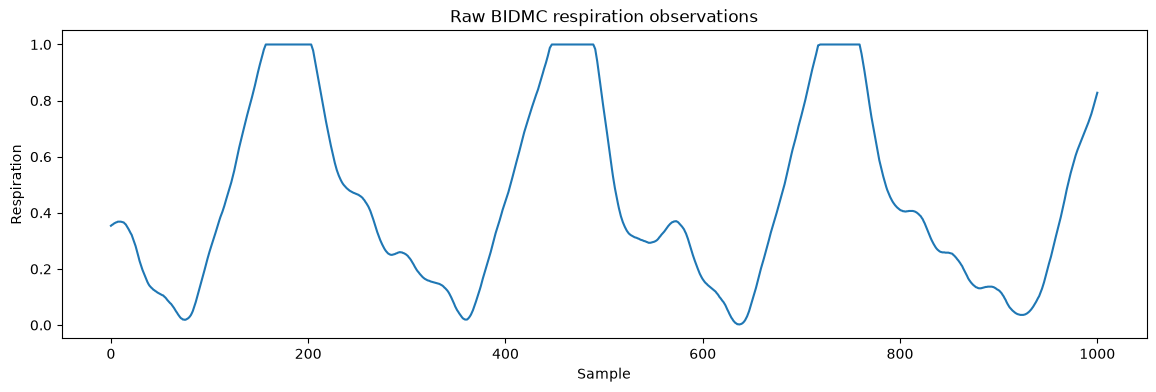

In [1]:
import featuregraph as fg
import matplotlib.pyplot as plt

bidmc = fg.datasets.bidmc(subject=1)

bidmc.loc[:1000].plot(
    y="respiration",
    figsize=(14, 4),
    legend=False,
    title="Raw BIDMC respiration observations",
)

plt.ylabel("Respiration")
plt.xlabel("Sample")
plt.show()

In [2]:
respiration = fg.oscillation.Oscillation(
    signals="respiration",
    group="subject",
    smooth_signal=False,
)

respiration_features = respiration.fit_transform(
    bidmc
)

respiration_objects = respiration.summarize(
    respiration_features,
    signal="respiration",
)

In [3]:
respiration_objects.table.head()

,subject,oscillation_id,is_complete,start_index,peak_index,end_index,rise_duration,fall_duration,duration,period,amplitude,rising_mean_rate,falling_mean_rate,peak_rise_rate,peak_fall_rate,temporal_symmetry
0,1,1,True,10.0,14.0,80.0,4,66,70,NaN,0.174974,0.087487,0.005302,0.001466,0.011535,0.114286
1,1,2,True,80.0,167.0,254.0,87,87,174,153.0,0.484849,0.011146,0.011146,0.015445,0.019452,1.000000
2,1,3,True,291.0,299.0,365.0,8,66,74,132.0,0.120235,0.030059,0.003643,0.000880,0.007038,0.216216
3,1,4,True,365.0,457.0,519.0,92,62,154,158.0,0.481427,0.010466,0.015530,0.013490,0.026002,0.805195
4,1,5,True,552.0,577.0,642.0,25,65,90,120.0,0.184262,0.014741,0.005670,0.004496,0.010753,0.555556


In [4]:
wave = respiration_objects.table.iloc[10]

start = int(wave["start_index"])
peak = int(wave["peak_index"])
end = int(wave["end_index"])

segment = bidmc.loc[start:end]

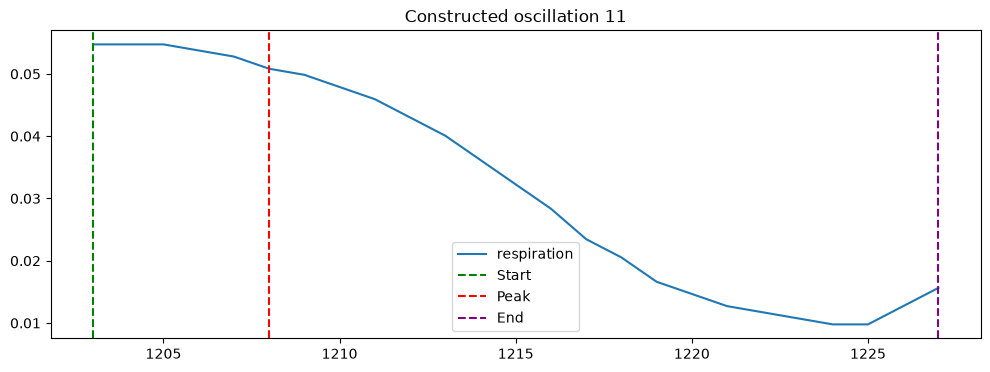

In [5]:
ax = segment.plot(
    y="respiration",
    figsize=(12, 4),
    legend=False,
    title=f"Constructed oscillation {wave['oscillation_id']}",
)

ax.axvline(
    start,
    color="green",
    linestyle="--",
    label="Start",
)

ax.axvline(
    peak,
    color="red",
    linestyle="--",
    label="Peak",
)

ax.axvline(
    end,
    color="purple",
    linestyle="--",
    label="End",
)

ax.legend()
plt.show()

In [6]:
wave[
    [
        "oscillation_id",
        "start_index",
        "peak_index",
        "end_index",
        "duration",
        "period",
        "amplitude",
        "temporal_symmetry",
    ]
]

oscillation_id             11
start_index            1203.0
peak_index             1208.0
end_index              1227.0
duration                   24
period                   67.0
amplitude            0.022483
temporal_symmetry    0.416667
Name: 10, dtype: object

In [7]:
long_oscillations = (
    respiration_objects
    .query()
    .where(duration__ge=100)
    .select(
        "oscillation_id",
        "start_index",
        "end_index",
        "duration",
        "amplitude",
    )
    .collect()
)

In [8]:
long_count = len(long_oscillations)
total_count = respiration_objects.count
percentage = 100 * long_count / total_count

{
    "long_oscillations": long_count,
    "total_oscillations": total_count,
    "percentage": percentage,
}

{'long_oscillations': 175,
 'total_oscillations': 545,
 'percentage': 32.11009174311926}

In [13]:
slow_symmetric_oscillations = (
    respiration_objects
    .query()
    .where(
        duration__ge=100,
        temporal_symmetry__ge=0.9,
    )
    .select(
        "oscillation_id",
        "duration",
        "amplitude",
        "temporal_symmetry",
    )
    .order_by(
        "amplitude",
        ascending=False,
    )
    .collect()
)

slow_symmetric_oscillations

,oscillation_id,duration,amplitude,temporal_symmetry
0,14,184,0.500000,0.989130
1,2,174,0.484849,1.000000
2,26,190,0.462855,0.926316
3,474,250,0.459922,0.928000
4,396,253,0.453079,0.916996
5,206,188,0.452591,0.925532
6,287,208,0.452591,0.903846
7,375,207,0.451613,0.927536
8,122,217,0.449660,0.949309
9,444,205,0.449170,0.936585


In [10]:
accumulation = fg.accumulation.Accumulation(
    signals="respiration",
    group="subject",
)

accumulation_features = accumulation.fit_transform(
    respiration_features
)

accumulation_objects = accumulation.summarize(
    accumulation_features,
    signal="respiration",
)

In [15]:
high_accumulation = (
    accumulation_objects
    .query()
    .where(total_auc__gt=50)
    .select(
        "accumulation_id",
        # "parent_oscillation_id",
        "total_auc",
        "accumulation_rate",
        "centroid_time",
    )
    .order_by(
        "total_auc",
        ascending=False,
    )
    .collect()
)

high_accumulation

,accumulation_id,total_auc,accumulation_rate,centroid_time
0,14,165.201413,0.573616,126.869486
1,412,146.278820,0.564783,135.486373
2,223,136.994400,0.593049,122.679138
3,158,136.219049,0.502653,156.782720
4,197,134.514970,0.468693,129.453433
...,...,...,...,...
160,437,74.717810,0.498119,101.203641
161,280,73.631366,0.433126,122.462907
162,57,68.185790,0.391872,93.335668
163,143,64.059400,0.520808,79.062658


In [16]:
eastman = fg.datasets.eastman(
    fault_number=1,
    simulation_run=1,
)

temperature = fg.oscillation.Oscillation(
    signals="reactor_temperature",
    group=[
        "fault_number",
        "simulation_run",
    ],
    smooth_signal=True,
    smooth_window=20,
)

temperature_features = temperature.fit_transform(
    eastman
)

temperature_objects = temperature.summarize(
    temperature_features,
    signal="reactor_temperature",
)

In [17]:
{
    "respiration": respiration_objects.properties,
    "reactor_temperature": temperature_objects.properties,
}

{'respiration': ('oscillation_id',
  'is_complete',
  'start_index',
  'peak_index',
  'end_index',
  'rise_duration',
  'fall_duration',
  'duration',
  'period',
  'amplitude',
  'rising_mean_rate',
  'falling_mean_rate',
  'peak_rise_rate',
  'peak_fall_rate',
  'temporal_symmetry'),
 'reactor_temperature': ('oscillation_id',
  'is_complete',
  'start_index',
  'peak_index',
  'end_index',
  'rise_duration',
  'fall_duration',
  'duration',
  'period',
  'amplitude',
  'rising_mean_rate',
  'falling_mean_rate',
  'peak_rise_rate',
  'peak_fall_rate',
  'temporal_symmetry')}